# Aufgabe 4

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 4.1

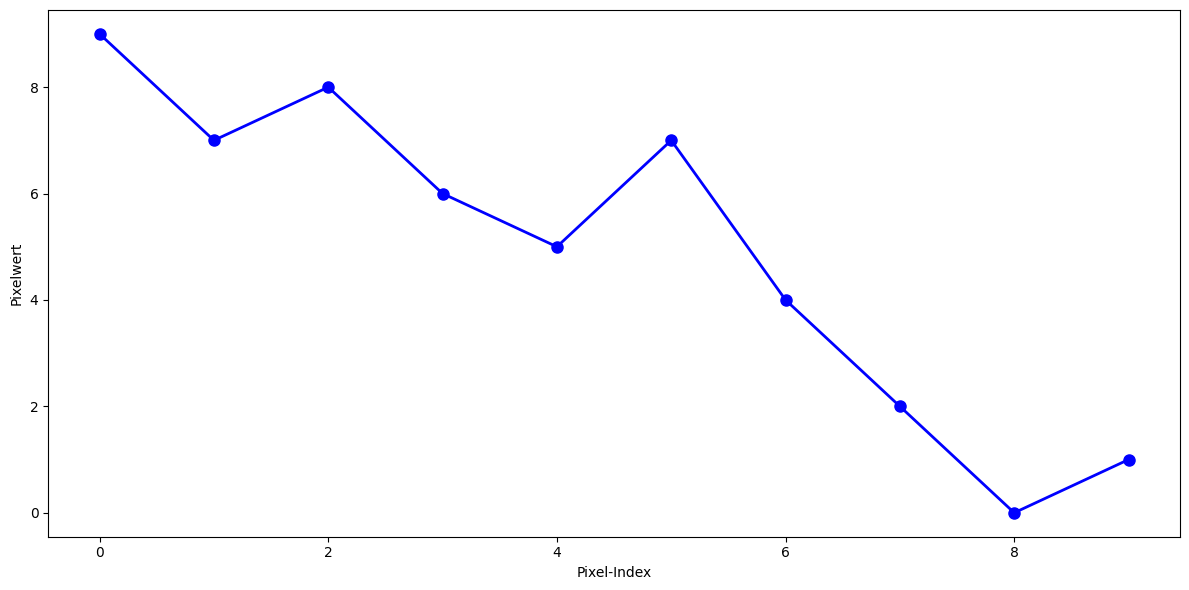

In [3]:
# Bildzeile definieren und plotten
image_line = np.array([9, 7, 8, 6, 5 ,7, 4, 2, 0 ,1], dtype=float)

plt.figure(figsize=(12, 6))
plt.plot(range(len(image_line)), image_line, 'bo-', label='Original Bildzeile', linewidth=2, markersize=8)
plt.xlabel('Pixel-Index')
plt.ylabel('Pixelwert')
plt.tight_layout()
plt.show()

## 4.2 & 4.3
Beide Teilaufgaben kombiniert, da mit der Funktion für das constant padding auch das zero padding durchgeführt werden kann.

In [4]:
# Aufgabe 2: Filterkern definieren und normieren
filter_kernel = np.array([1, 1, 1, 1, 1], dtype=float)
# Normierung: Summe der Einträge = 1
filter_kernel_normalized = filter_kernel / np.sum(filter_kernel)

print("Original Filterkern:", filter_kernel)
print("Normierter Filterkern:", filter_kernel_normalized)
print("Summe des normierten Filters:", np.sum(filter_kernel_normalized))

Original Filterkern: [1. 1. 1. 1. 1.]
Normierter Filterkern: [0.2 0.2 0.2 0.2 0.2]
Summe des normierten Filters: 1.0


In [5]:
def convolution_1d_constant_padding(image, kernel, padding_value=0):
    """
    Implementiert die 1D-Faltung mit Constant-Padding.
    
    Parameter:
    - image: 1D-Array (Bildzeile)
    - kernel: 1D-Array (Filterkern)
    - padding_value: Der konstante Wert für das Padding
    
    Rückgabe:
    - convolved: 1D-Array mit gleicher Länge wie image
    """
    kernel_size = len(kernel)
    image_size = len(image)
    
    # Padding-Größe berechnen (auf beiden Seiten)
    padding_size = kernel_size // 2
    
    # Constant-Padding anwenden (manuell, ohne numpy.pad)
    padded_image = np.full(image_size + 2 * padding_size, padding_value, dtype=float)
    padded_image[padding_size:padding_size + image_size] = image
    
    # Faltung durchführen
    convolved = np.zeros(image_size)
    
    for i in range(image_size):
        # Fenster extrahieren (mit Padding berücksichtigt)
        window = padded_image[i:i + kernel_size]
        # Elementweise Multiplikation und Summation
        convolved[i] = np.sum(window * kernel)
    
    return convolved


In [6]:
# Zero-Padding Faltung durchführen
result_zero_padding = convolution_1d_constant_padding(
    image=image_line,
    kernel=filter_kernel_normalized,
    padding_value=0
)

# Constant-Padding Faltung durchführen mit Wert 9
result_constant_padding = convolution_1d_constant_padding(
    image_line,
    filter_kernel_normalized,
    padding_value=9
)

## 4.4 Replicate padding

In [7]:
def convolution_1d_replicate_padding(image, kernel):
    """
    Implementiert die 1D-Faltung mit Replicate-Padding.
    
    Parameter:
    - image: 1D-Array (Bildzeile)
    - kernel: 1D-Array (Filterkern)
    
    Rückgabe:
    - convolved: 1D-Array mit gleicher Länge wie image
    """
    kernel_size = len(kernel)
    image_size = len(image)
    
    # Padding-Größe berechnen (auf beiden Seiten)
    padding_size = kernel_size // 2
    
    # Padding initialisieren
    padded_image = np.zeros(image_size + 2 * padding_size)
    
    # Original-Bildzeile in die Mitte kopieren
    padded_image[padding_size:padding_size + image_size] = image
    
    # Linke Seite: erste Werte replizieren
    padded_image[:padding_size] = image[0]
    
    # Rechte Seite: letzte Werte replizieren
    padded_image[padding_size + image_size:] = image[-1]
    
    # Faltung durchführen
    convolved = np.zeros(image_size)
    
    for i in range(image_size):
        # Fenster extrahieren (mit Padding berücksichtigt)
        window = padded_image[i:i + kernel_size]
        # Elementweise Multiplikation und Summation
        convolved[i] = np.sum(window * kernel)
    
    return convolved

In [8]:
# Replicate-Padding Faltung durchführen
result_replicate_padding = convolution_1d_replicate_padding(image_line, filter_kernel_normalized)

# 4.5 Reflect padding

In [9]:
def convolution_1d_reflect_padding(image, kernel):
    """
    Implementiert die 1D-Faltung mit Reflect-Padding (Spiegelung ohne Randwert).
    
    Parameter:
    - image: 1D-Array (Bildzeile)
    - kernel: 1D-Array (Filterkern)
    
    Rückgabe:
    - convolved: 1D-Array mit gleicher Länge wie image
    """
    kernel_size = len(kernel)
    image_size = len(image)
    
    # Padding-Größe berechnen (auf beiden Seiten)
    padding_size = kernel_size // 2
    
    # Padding initialisieren
    padded_image = np.zeros(image_size + 2 * padding_size)
    
    # Original-Bildzeile in die Mitte kopieren
    padded_image[padding_size:padding_size + image_size] = image
    
    # Linke Seite: Werte spiegeln ohne den Randwert selbst
    padded_image[:padding_size] = image[1:padding_size+1][::-1]
    
    # Rechte Seite: Werte spiegeln ohne den Randwert selbst
    padded_image[padding_size + image_size:] = image[-padding_size-1:-1][::-1]
    
    # Faltung durchführen
    convolved = np.zeros(image_size)
    
    for i in range(image_size):
        # Fenster extrahieren (mit Padding berücksichtigt)
        window = padded_image[i:i + kernel_size]
        # Elementweise Multiplikation und Summation
        convolved[i] = np.sum(window * kernel)
    
    return convolved

In [10]:
# Reflect-Padding Faltung durchführen
result_reflect_padding = convolution_1d_reflect_padding(image_line, filter_kernel_normalized)

## 4.6 Wrap-around padding

In [11]:
def convolution_1d_wrap_around_padding(image, kernel):
    """
    Implementiert die 1D-Faltung mit Wrap-Around-Padding (Periodic/Circular Padding).
    
    Parameter:
    - image: 1D-Array (Bildzeile)
    - kernel: 1D-Array (Filterkern)
    
    Rückgabe:
    - convolved: 1D-Array mit gleicher Länge wie image
    """
    kernel_size = len(kernel)
    image_size = len(image)
    
    # Padding-Größe berechnen (auf beiden Seiten)
    padding_size = kernel_size // 2
    
    # Padding initialisieren
    padded_image = np.zeros(image_size + 2 * padding_size)
    
    # Original-Bildzeile in die Mitte kopieren
    padded_image[padding_size:padding_size + image_size] = image
    
    # Linke Seite: Werte vom Ende der Bildzeile (wrap around)
    padded_image[:padding_size] = image[-padding_size:]
    
    # Rechte Seite: Werte vom Anfang der Bildzeile (wrap around)
    padded_image[padding_size + image_size:] = image[:padding_size]
    
    # Faltung durchführen
    convolved = np.zeros(image_size)
    
    for i in range(image_size):
        # Fenster extrahieren (mit Padding berücksichtigt)
        window = padded_image[i:i + kernel_size]
        # Elementweise Multiplikation und Summation
        convolved[i] = np.sum(window * kernel)
    
    return convolved

In [12]:
# Wrap-Around-Padding Faltung durchführen
result_wrap_around_padding = convolution_1d_wrap_around_padding(image_line, filter_kernel_normalized)

## Vergleich und Analyse aller Padding-Methoden

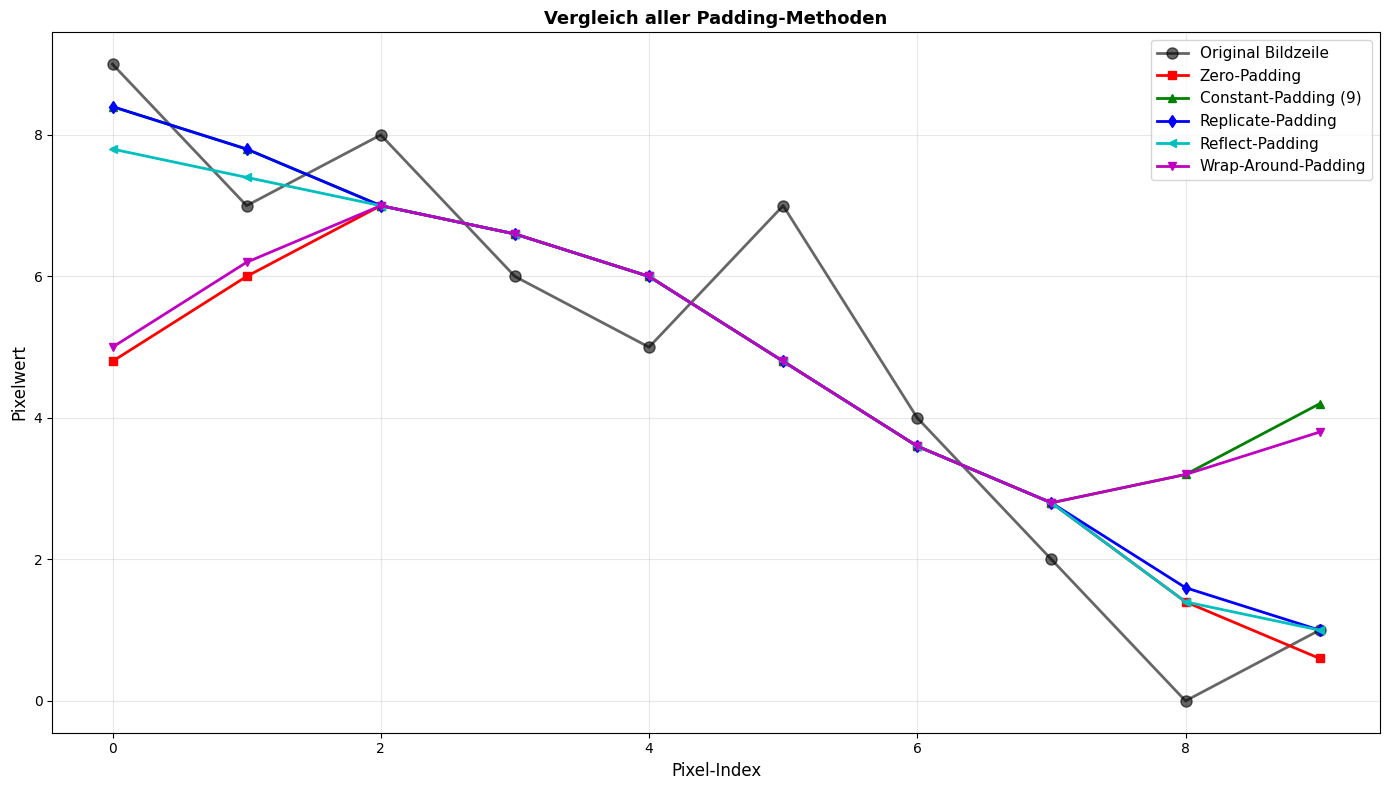

In [14]:
# Vergleich: Zero-Padding vs. Constant-Padding vs. Replicate-Padding vs. Wrap-Around-Padding
plt.figure(figsize=(14, 8))

# Plot alle Faltungsergebnisse
plt.plot(range(len(image_line)), image_line, 'ko-', label='Original Bildzeile', linewidth=2, markersize=8, alpha=0.6)
plt.plot(range(len(result_zero_padding)), result_zero_padding, 'rs-', label='Zero-Padding', linewidth=2, markersize=6)
plt.plot(range(len(result_constant_padding)), result_constant_padding, 'g^-', label='Constant-Padding (9)', linewidth=2, markersize=6)
plt.plot(range(len(result_replicate_padding)), result_replicate_padding, 'bd-', label='Replicate-Padding', linewidth=2, markersize=6)
plt.plot(range(len(result_reflect_padding)), result_reflect_padding, 'c<-', label='Reflect-Padding', linewidth=2, markersize=6)
plt.plot(range(len(result_wrap_around_padding)), result_wrap_around_padding, 'mv-', label='Wrap-Around-Padding', linewidth=2, markersize=6)

plt.xlabel('Pixel-Index', fontsize=12)
plt.ylabel('Pixelwert', fontsize=12)
plt.title('Vergleich aller Padding-Methoden', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analyse der Padding-Methoden

**Auswirkungen auf Randpixel:**
- **Zero-Padding**: Erzeugt niedrigere Werte an den Rändern, da die Nullen den Durchschnitt senken.
- **Constant-Padding (9)**: Liefert am linken Rand ein gutes Ergebnis, aber der Wert am rechten Rand ist deutlich zu hoch, da der originale Wert sehr klein ist im Vergleich.
- **Replicate-Padding**: Erzeugt sehr gute Ergebnisse durch Wiederholung der Randwerte. Beste Annäherung an die innere Struktur.
- **Reflect-Padding**: Spiegelt die Werte ohne den Randwert selbst. Produziert ähnlich gute Ergebnisse wie Replicate-Padding, mit etwas sanfteren Übergängen.
- **Wrap-Around-Padding**: Verbindet Anfang und Ende zyklisch. Da der sehr kleine Originalwert vom rechten Rand neben dem sehr hohen Wert vom linken Rand steht, sind die Randwerte sehr schlecht.

**Fazit:** Replicate- und Reflect-Padding liefern die besten Ergebnisse. Reflect-Padding hat einen Vorteil bei sanfteren Übergängen.